# Projections and Components

## Purpose

Understand projection as the part of one vector that lies in the direction of another, and use it to split a vector into parallel and perpendicular components.

By the end of this notebook I should be able to:

- explain projection as the part of one vector that lies along another vector
- calculate scalar projection and vector projection
- split a vector into parallel and perpendicular components
- check that the perpendicular component really is perpendicular
- connect projection to the geometry of a triangle
- recognise why projection matters for least squares and machine learning


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Helpers

These helpers keep the plotting setup out of the learning examples.

They are deliberately simple and 2D-only because this notebook is focused on intuition.


In [2]:
def setup_vector_plot(xlim=(-1, 6), ylim=(-1, 5), figsize=(6, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    return fig, ax


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    color=None,
    width=0.006,
):
    origin = np.array(origin, dtype=float)
    v = np.array(v, dtype=float)

    ax.quiver(
        origin[0],
        origin[1],
        v[0],
        v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=width,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def draw_dashed_line(ax, start, end):
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)
    ax.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        linestyle="--",
    )


def draw_point(ax, point, label=None, label_offset=(0.1, 0.1)):
    point = np.array(point, dtype=float)
    ax.scatter(point[0], point[1])

    if label:
        ax.text(
            point[0] + label_offset[0],
            point[1] + label_offset[1],
            label,
            fontsize=10,
        )


## Recap: dot product and cosine similarity

In the previous notebook, the dot product measured how aligned two vectors were.

For two vectors \(a\) and \(b\):

$$
a \cdot b = \|a\| \|b\| \cos(\theta)
$$

This means the dot product combines two things:

- the lengths of the vectors
- the direction/alignment between them

Cosine similarity removes the effect of length:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\| \|b\|}
$$

Projection builds directly on this idea.


In [3]:
a = np.array([4, 3])
b = np.array([5, 0])

dot_ab = a @ b
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
cosine_similarity = dot_ab / (norm_a * norm_b)

print("a:", a)
print("b:", b)
print("a · b:", dot_ab)
print("||a||:", norm_a)
print("||b||:", norm_b)
print("cosine similarity:", cosine_similarity)


a: [4 3]
b: [5 0]
a · b: 20
||a||: 5.0
||b||: 5.0
cosine similarity: 0.8


## What does projection mean?

A projection answers the question:

> How much of one vector lies in the direction of another vector?

In this notebook, I will use the following language:

- the **object vector** is the vector being projected
- the **target vector** is the vector being projected onto

So:

$$
\operatorname{proj}_b(a)
$$

means:

> the projection of object vector \(a\) onto target vector \(b\)

The projection does not keep the whole original vector.

It keeps only the part that lies along the target direction.


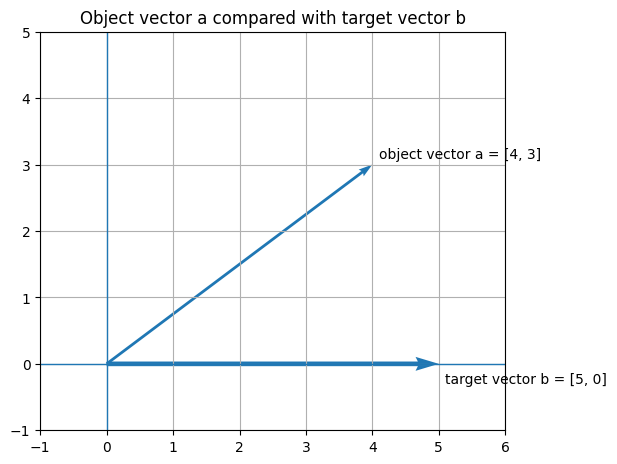

In [4]:
fig, ax = setup_vector_plot()

draw_vector(ax, a, label="object vector a = [4, 3]", label_offset=(0.1, 0.1))
draw_vector(ax, b, label="target vector b = [5, 0]", label_offset=(0.1, -0.3), width=0.01)

ax.set_title("Object vector a compared with target vector b")
plt.show()


## Projection as a rotated-axis idea

One useful mental model is to imagine rotating the coordinate system so that the target vector becomes the main \( \hat{i} \) direction.

In that rotated coordinate system, the object vector has:

- an amount in the target direction
- an amount sideways from the target direction

The projection is the target-direction part turned back into a vector in the original coordinate system.

So projection is a bit like asking:

> If the target vector were my x-axis, what is the x-axis part of the object vector?

That is not how we usually calculate it directly, but it is a good way to think about what the calculation is doing.


## Scalar projection

The scalar projection tells us the signed length of the part of \(a\) that lies in the direction of \(b\).

It is calculated as:

$$
\operatorname{scalar\ projection}_{b}(a) =
\frac{a \cdot b}{\|b\|}
$$

This gives a number, not a vector.

A convenient way to think about this is:

1. turn \(b\) into a unit vector
2. dot \(a\) with that unit vector

The result is the amount of \(a\) in the direction of \(b\).


In [5]:
unit_b = b / np.linalg.norm(b)
scalar_projection = a @ unit_b

print("unit_b:", unit_b)
print("Scalar projection of a onto b:", scalar_projection)


unit_b: [1. 0.]
Scalar projection of a onto b: 4.0


The scalar projection is `4.0`.

That makes sense visually: vector \(a = [4, 3]\) moves 4 units in the x direction, and \(b = [5, 0]\) points exactly along the x-axis.

So the part of \(a\) that lies in the direction of \(b\) has length 4.


## Vector projection

The scalar projection gives a length.

The vector projection gives the actual vector in the target direction.

To get the vector projection:

1. calculate the scalar projection
2. multiply it by the unit vector in the target direction

$$
\operatorname{proj}_b(a) =
(a \cdot \hat{b}) \hat{b}
$$

where:

$$
\hat{b} = \frac{b}{\|b\|}
$$

Another common version of the same formula is:

$$
\operatorname{proj}_b(a) =
\frac{a \cdot b}{b \cdot b} b
$$


In [6]:
vector_projection = scalar_projection * unit_b

print("Vector projection of a onto b:", vector_projection)


Vector projection of a onto b: [4. 0.]


For this simple example:

$$
a = [4, 3]
$$

and:

$$
b = [5, 0]
$$

The projection is:

$$
\operatorname{proj}_b(a) = [4, 0]
$$

This is the base-aligned part of \(a\).


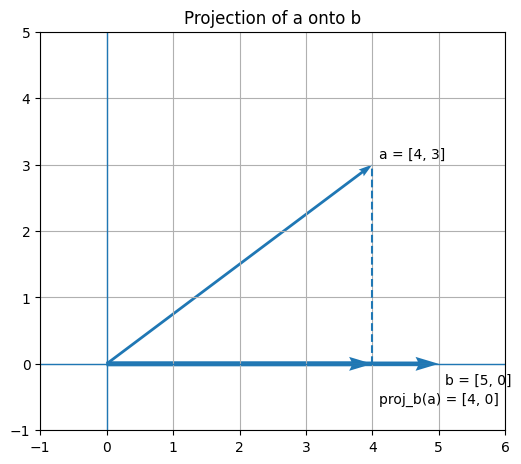

In [7]:
fig, ax = setup_vector_plot()

draw_vector(ax, a, label="a = [4, 3]", label_offset=(0.1, 0.1))
draw_vector(ax, b, label="b = [5, 0]", label_offset=(0.1, -0.3), width=0.01)
draw_vector(
    ax,
    vector_projection,
    label="proj_b(a) = [4, 0]",
    label_offset=(0.1, -0.6),
    width=0.01,
)

draw_dashed_line(ax, vector_projection, a)

ax.set_title("Projection of a onto b")
plt.show()


## Projection and the triangle picture

Another useful mental model is the triangle picture.

Imagine:

- \(O\) is the origin
- \(A\) is the end of the object vector \(a\)
- \(B\) is the end of the target/base vector \(b\)
- \(H\) is the foot of the perpendicular from \(A\) to the line through \(b\)

Then the projection is:

$$
\operatorname{proj}_b(a) = \overrightarrow{OH}
$$

That is the key correction:

> The projection is not the height of the triangle.

The projection is the vector from the origin to the point where the height line hits the base line.

So projection tells us:

> where the perpendicular from \(A\) intersects the base line, and how far that point is from the origin along the base direction.

The height is the leftover part:

$$
a - \operatorname{proj}_b(a)
$$


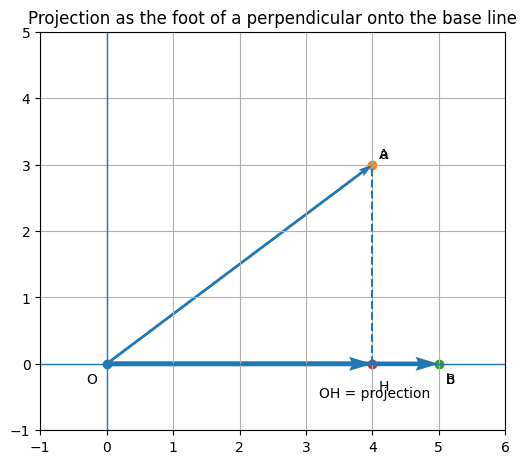

In [8]:
origin = np.array([0, 0])
A = a
B = b
H = vector_projection

fig, ax = setup_vector_plot()

draw_point(ax, origin, "O", label_offset=(-0.3, -0.3))
draw_point(ax, A, "A", label_offset=(0.1, 0.1))
draw_point(ax, B, "B", label_offset=(0.1, -0.3))
draw_point(ax, H, "H", label_offset=(0.1, -0.4))

draw_vector(ax, a, label="a", label_offset=(0.1, 0.1))
draw_vector(ax, b, label="b", label_offset=(0.1, -0.3), width=0.01)
draw_vector(ax, H, label="OH = projection", label_offset=(-0.8, -0.5), width=0.01)

draw_dashed_line(ax, H, A)

ax.set_title("Projection as the foot of a perpendicular onto the base line")
plt.show()


## Parallel and perpendicular components

Projection lets us split the object vector into two parts:

$$
a = a_{\parallel} + a_{\perp}
$$

where:

$$
a_{\parallel} = \operatorname{proj}_b(a)
$$

and:

$$
a_{\perp} = a - \operatorname{proj}_b(a)
$$

The parallel component lies along the target vector.

The perpendicular component is at right angles to the target vector.


In [9]:
parallel_component = vector_projection
perpendicular_component = a - parallel_component

print("a:", a)
print("parallel component:", parallel_component)
print("perpendicular component:", perpendicular_component)
print("parallel + perpendicular:", parallel_component + perpendicular_component)


a: [4 3]
parallel component: [4. 0.]
perpendicular component: [0. 3.]
parallel + perpendicular: [4. 3.]


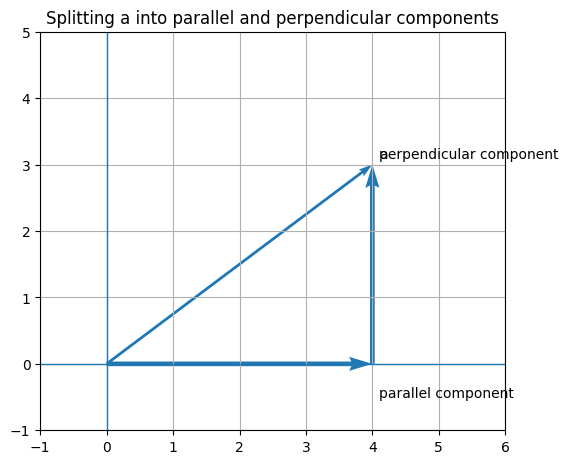

In [10]:
fig, ax = setup_vector_plot()

draw_vector(ax, a, label="a", label_offset=(0.1, 0.1))
draw_vector(
    ax,
    parallel_component,
    label="parallel component",
    label_offset=(0.1, -0.5),
    width=0.01,
)
draw_vector(
    ax,
    perpendicular_component,
    origin=parallel_component,
    label="perpendicular component",
    label_offset=(0.1, 0.1),
    width=0.01,
)

ax.set_title("Splitting a into parallel and perpendicular components")
plt.show()


The picture shows the decomposition:

$$
a = a_{\parallel} + a_{\perp}
$$

In this example:

$$
[4, 3] = [4, 0] + [0, 3]
$$

The projection gives the parallel component.

The leftover part gives the perpendicular component.


## Checking the decomposition

The perpendicular component should really be perpendicular to \(b\).

Two non-zero vectors are perpendicular if their dot product is zero.

So we can check:

$$
a_{\perp} \cdot b = 0
$$


In [11]:
perpendicular_dot_target = perpendicular_component @ b

print("perpendicular component · b:", perpendicular_dot_target)


perpendicular component · b: 0.0


The result is zero, so the leftover component really is perpendicular to the target vector.

This gives us a useful way to check that the projection calculation worked.


## Height of the triangle

If \(b\) is used as the base of a triangle, then the triangle height is the length of the perpendicular component.

So:

$$
\text{height} = \|a - \operatorname{proj}_b(a)\|
$$

For this example, the perpendicular component is:

$$
[0, 3]
$$

so the height is 3.


In [12]:
height = np.linalg.norm(perpendicular_component)
base_length = np.linalg.norm(b)
triangle_area = 0.5 * base_length * height

print("base length:", base_length)
print("height:", height)
print("triangle area:", triangle_area)


base length: 5.0
height: 3.0
triangle area: 7.5


This is a useful separation:

- projection = where the height line lands on the base line
- perpendicular component = the height direction
- height = length of the perpendicular component


## A less axis-aligned example

The previous example was deliberately simple because the target vector pointed along the x-axis.

Now use a target vector that is not horizontal.

The same formulas still work.


In [13]:
a = np.array([4, 3])
b = np.array([3, 1])

unit_b = b / np.linalg.norm(b)
scalar_projection = a @ unit_b
vector_projection = scalar_projection * unit_b
perpendicular_component = a - vector_projection

print("a:", a)
print("b:", b)
print("unit_b:", unit_b)
print("scalar projection:", scalar_projection)
print("vector projection:", vector_projection)
print("perpendicular component:", perpendicular_component)
print("perpendicular component · b:", perpendicular_component @ b)


a: [4 3]
b: [3 1]
unit_b: [0.9486833  0.31622777]
scalar projection: 4.743416490252569
vector projection: [4.5 1.5]
perpendicular component: [-0.5  1.5]
perpendicular component · b: 0.0


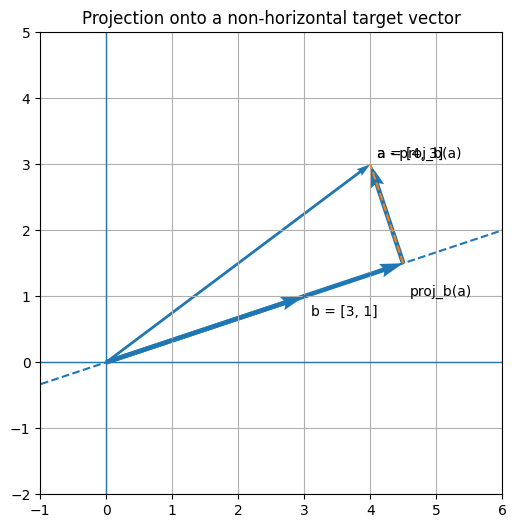

In [14]:
fig, ax = setup_vector_plot(xlim=(-1, 6), ylim=(-2, 5))

# Draw the full target line, not just the target vector.
line_scale = 2
line_start = -line_scale * b
line_end = line_scale * b
draw_dashed_line(ax, line_start, line_end)

draw_vector(ax, a, label="a = [4, 3]", label_offset=(0.1, 0.1))
draw_vector(ax, b, label="b = [3, 1]", label_offset=(0.1, -0.3), width=0.01)
draw_vector(
    ax,
    vector_projection,
    label="proj_b(a)",
    label_offset=(0.1, -0.5),
    width=0.01,
)
draw_vector(
    ax,
    perpendicular_component,
    origin=vector_projection,
    label="a - proj_b(a)",
    label_offset=(0.1, 0.1),
    width=0.01,
)

draw_dashed_line(ax, vector_projection, a)

ax.set_title("Projection onto a non-horizontal target vector")
plt.show()


This second example is closer to the general case.

The projection still lands on the line through the target vector.

The perpendicular component still leaves the target line at a right angle.

The check:

$$
(a - \operatorname{proj}_b(a)) \cdot b = 0
$$

still confirms that the leftover part is perpendicular to the target direction.


## Why this matters for least squares

Projection is not just a geometry trick.

It becomes important when trying to find the best approximation to something.

In least squares, the core idea is:

> Find the best prediction, then look at the leftover error.

That leftover error is called a residual.

In geometric terms, least squares often tries to make the residual perpendicular to the space of possible predictions.

This notebook has shown the small 2D version of that idea:

$$
a = a_{\parallel} + a_{\perp}
$$

where:

- \(a_{\parallel}\) is the projected/best-aligned part
- \(a_{\perp}\) is the leftover/residual part
- the residual is perpendicular to the target direction

This idea scales up from 2D pictures to higher-dimensional linear algebra.


## Summary

Projection splits one vector relative to another vector.

Given an object vector \(a\) and a target vector \(b\):

$$
\operatorname{proj}_b(a) =
\frac{a \cdot b}{b \cdot b} b
$$

The projection is the part of \(a\) that lies along \(b\).

The perpendicular component is:

$$
a - \operatorname{proj}_b(a)
$$

Together:

$$
a =
\operatorname{proj}_b(a)
+
(a - \operatorname{proj}_b(a))
$$

The important mental models are:

- projection is like treating the target vector as the main axis, then asking how much of the object vector lies along that axis
- projection is the point where the perpendicular from the object vector lands on the target/base line
- the perpendicular component is the leftover part after the projection
- the length of the perpendicular component is the height if the target vector is treated as the base of a triangle


## Next step

The natural next notebook is matrices and linear transformations.

Projection has shown how vectors can be split into meaningful parts.

Matrices will show how vectors can be transformed systematically: stretched, rotated, reflected, sheared, and combined.
